# Part 2

## Step 1
### Process speeches using the SpaCy nlp module

We import libraries and dataset, after we also change the datatype from float to int type.

In [26]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from tqdm import tqdm
from collections import Counter
from utils import *

plt.style.use('seaborn-v0_8-dark')

# read in SOTU.csv
sou_original = pd.read_csv('./data/SOTU.csv')
sou = edit_year(sou_original)

we load the English languange processing model, subset the speeches after 1999, finally we apply the nlp model to the column "Text" in our dataset.

In [27]:
nlp = spacy.load("en_core_web_sm")

In [28]:
# subset the speech dataframe for speeches from 2000 and onwards
sou = sou[sou['Year'] >= 2000]

In [29]:
# Process each speech using the 'nlp' function
sou_text = sou["Text"].apply(nlp)

After applying the nlp model, we extract the speeches from each of the rows present in the column "Text".

In [30]:
# list of all speeches from => 2000
speeches = [token for token in sou_text]

In [31]:
type(speeches[0])

spacy.tokens.doc.Doc

## Step 2
### Analyze Tokens vs Lemmas

#### Token List
List of tokens without stop words, punctuation or spaces.

For the next cell, we extract all the tokens (words) from each of the speeches. This list then gets filtered and changed to lower case, the filtering is done through the function `is_token_allowed`, which can be found in the utils.py module. This function essentially checks if the token is a stop word, punctuation or a space.

In [32]:
token_list = [token for s in speeches for token in s]

complete_filtered_tokens = [
    token.lower_
    for token in token_list
    if is_token_allowed(token)
]

Finally, we get the top 20 most common words for the speeches made after 2000. As we can see, the top 6 has 3 words with the same root "america", "american" and "americans", which may skew a little our analysis in terms of the actual words. This is a reason why we would actully prefer to deal with lemmas instead of tokens.

In [33]:
top_tokens = Counter(complete_filtered_tokens).most_common(20)
top_tokens

[('america', 816),
 ('people', 637),
 ('american', 582),
 ('new', 530),
 ('years', 439),
 ('americans', 437),
 ('world', 425),
 ('year', 406),
 ('country', 369),
 ('jobs', 348),
 ('tonight', 344),
 ('work', 324),
 ('know', 323),
 ('let', 320),
 ('congress', 317),
 ('nation', 311),
 ('time', 301),
 ('help', 282),
 ('need', 266),
 ('tax', 255)]

#### Lemma List
List of lemmas without stop words, punctuation or spaces. We do the exact same thing that we did with tokens in the past cells, however we are adding the extra step where we apply it to lemmas, an attribute of the tokens themselves.

In [34]:
complete_filtered_lemmas = [
    token.lemma_.lower()
    for token in token_list
    if is_token_allowed(token)
]

In [35]:
top_lemmas = Counter(complete_filtered_lemmas).most_common(20)
top_lemmas

[('year', 845),
 ('america', 816),
 ('people', 639),
 ('american', 587),
 ('work', 557),
 ('new', 532),
 ('job', 486),
 ('country', 435),
 ('americans', 432),
 ('world', 426),
 ('know', 395),
 ('nation', 388),
 ('help', 378),
 ('need', 353),
 ('time', 351),
 ('tonight', 344),
 ('child', 332),
 ('let', 326),
 ('congress', 317),
 ('come', 301)]

#### Token versus Lemma Comparison

In [36]:
list_matches = [l[0] for l in top_lemmas for t in top_tokens if l[0] == t[0]]
len(list_matches)

17

On the previous cell we compared elements in the list of top tokens vs the list of top lemmas to see how many of the lemmas we could find in the token list. Considering the cases like **year** and **years** that ended up being the same lemma in the latter list, more than 85% of tokens were also part of the lemma list.
For the lemma 'child' it wasn't originally part of the token list, but when considering the core component, it probably considered words like **children**. 

## Step 3
### Analyze common word distributions over different years

#### Common Words

We now join everything that we have done in separate steps into a function that does this for us. It is directly the compilation of all steps merged into the function `get_most_common_words`. We then test it on 2024 and get data for 2023 and 2017 to later compare.

In [37]:
def get_most_common_words(df, year, n=25):
    """
    Processes the SOTU speech for a given year and returns
    the most common non-stopword/punctuation lemmas.
    """
    # subsetting df
    df = edit_year(df)
    df = df[df['Year'] == year]

    # text processing
    nlp = spacy.load("en_core_web_sm")
    df_text = df["Text"].apply(nlp)
    
    speeches = [token for token in df_text]
    token_list = [token for s in speeches for token in s]
    
    list_lemmas = [
    token.lemma_.lower()
    for token in token_list
    if is_token_allowed(token)
    ]

    # get lemmas
    count_n = Counter(list_lemmas).most_common(n)
    
    return count_n

In [38]:
# testing with 2024
get_most_common_words(sou_original, 2024, n=10)

[('president', 58),
 ('year', 45),
 ('america', 44),
 ('american', 34),
 ('people', 33),
 ('$', 33),
 ('member', 32),
 ('want', 29),
 ('audience', 29),
 ('know', 29)]

In [39]:
words_2023 = get_most_common_words(sou_original, 2023, n=20)
words_2017 = get_most_common_words(sou_original, 2017, n=20)

In [40]:
words_2023

[('year', 58),
 ('go', 56),
 ('let', 45),
 ('know', 40),
 ('people', 39),
 ('job', 38),
 ('america', 36),
 ('come', 33),
 ('law', 33),
 ('pay', 33),
 ('american', 31),
 ('$', 31),
 ('president', 30),
 ('look', 27),
 ('world', 25),
 ('folk', 24),
 ('nation', 24),
 ('audience', 23),
 ('work', 23),
 ('right', 23)]

In [41]:
words_2017

[('american', 34),
 ('america', 29),
 ('country', 26),
 ('nation', 21),
 ('great', 20),
 ('new', 19),
 ('year', 19),
 ('world', 18),
 ('job', 15),
 ('people', 15),
 ('americans', 14),
 ('united', 13),
 ('tonight', 13),
 ('states', 12),
 ('work', 12),
 ('child', 12),
 ('want', 12),
 ('time', 12),
 ('citizen', 11),
 ('right', 11)]

Turning the results into dataframes to plot them easier.

In [42]:
df_2017 = pd.DataFrame(words_2017, columns=['Word', 'Count'])
df_2023 = pd.DataFrame(words_2023, columns=['Word', 'Count'])

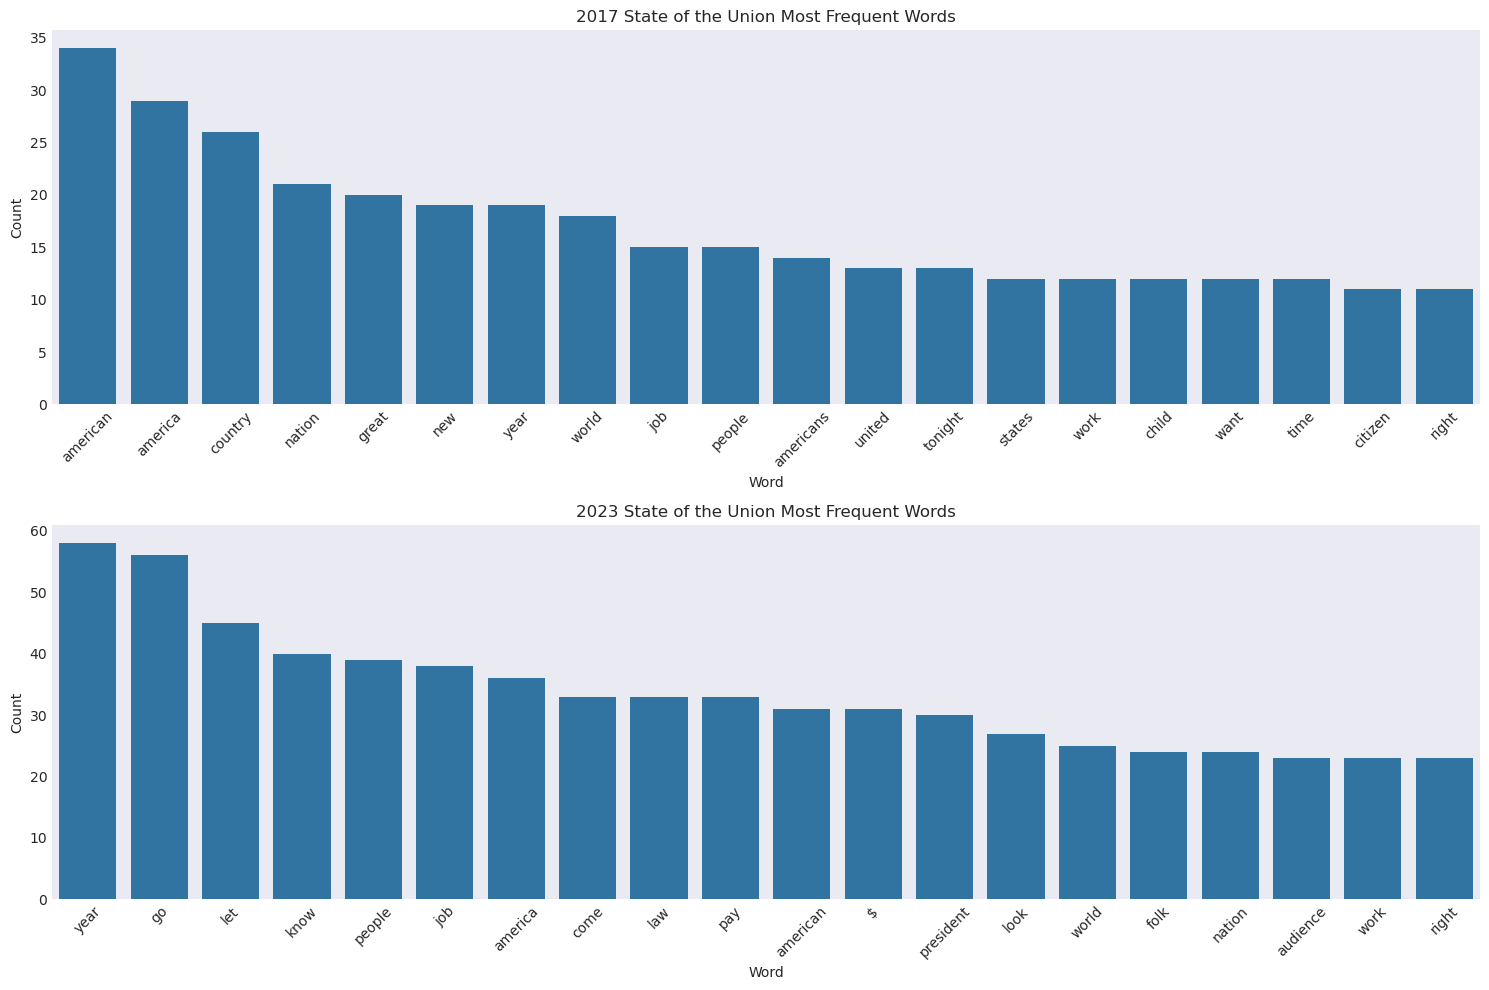

In [43]:
fig, axes = plt.subplots(2,1,figsize=(15, 10))

# 2017
sns.barplot(ax=axes[0], x = df_2017.Word,y = df_2017.Count)
axes[0].set_title("2017 State of the Union Most Frequent Words")
axes[0].tick_params(axis='x', rotation=45)

# 2023
sns.barplot(ax=axes[1], x = df_2023.Word,y = df_2023.Count)
axes[1].set_title("2023 State of the Union Most Frequent Words")
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.savefig("outputs/2017_2023_most_freq.png")

From our plots we can first observe that the most common word for 2017 was mentioned a little bit over half of the times compared to how much its 2023 counterpart was mentioned. For both years both top 20s contain a lot of monosilabic words, and for 2023 even a symbol (talking about money) is included into the top 20.

On 2017, "america" and "american" are in the first two positions of the barplot, while for 2023, "year" and "go" take the same places. For the 20th position, in both years "right" was the word mentioned.

## Step 4
### TF-IDF Vectorization

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

#### Training the Vectorizer and Transform the Data


In [45]:
# you may use this as input to fit the TF-IDF vectorizer
raw_docs = sou["Text"].to_list()

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=None
)

tfidf_matrix = vectorizer.fit_transform(raw_docs)

tfidf_matrix.shape

(25, 8698)

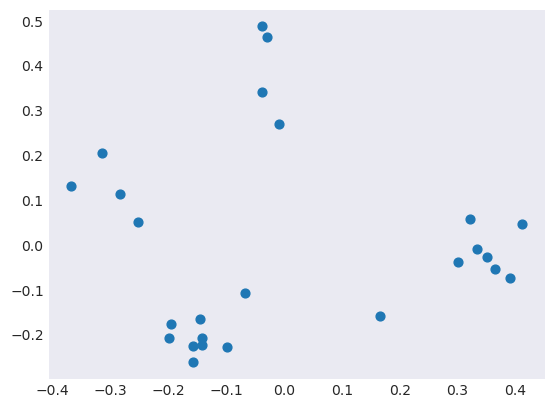

<Figure size 640x480 with 0 Axes>

In [46]:
# Step 1: Set PCA to find first 2 principal components

# vectorization
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(raw_docs)

# find the first 2 principal components
pca = PCA(n_components=2, random_state=0)

# Fit PCA on matrix
X_pca = pca.fit_transform(tfidf_matrix.toarray())

# Step 2: Create a new dataframe where each row is a speech, and each column is a projection onto
# one of the two principal components
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Year"] = sou["Year"].values
df_pca

# Plot Data Visualization (Matplotlib)
plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    s=40
)

plt.show()
plt.savefig("outputs/PCA.png")

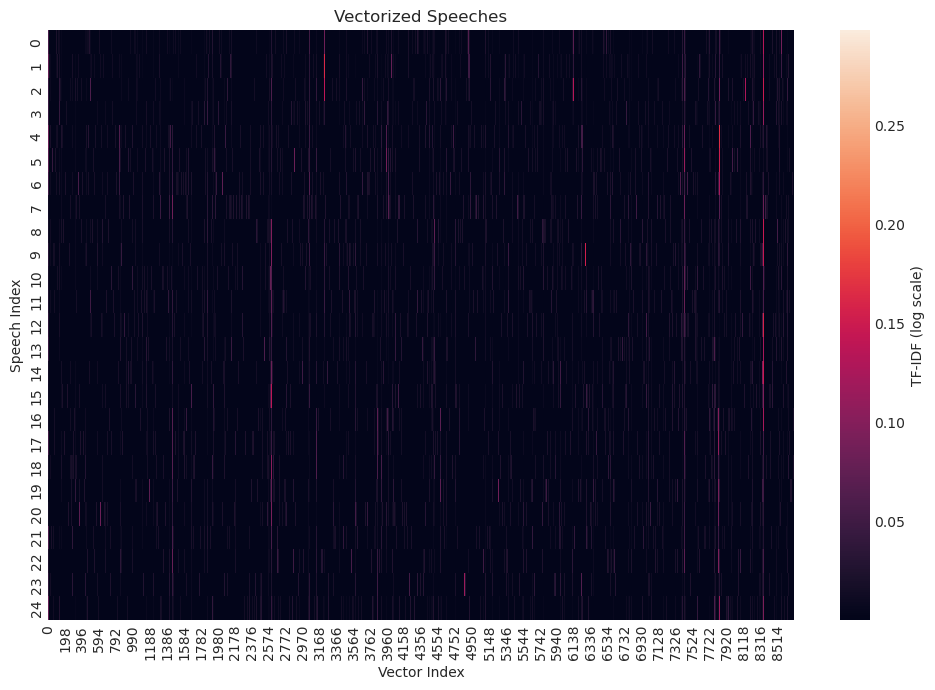

<Figure size 640x480 with 0 Axes>

In [49]:
dense = tfidf_matrix.toarray()

plt.figure(figsize=(10, 7))

sns.heatmap(
    dense + 1e-6, # kept getting a missing data error without this
    cbar_kws={"label": "TF-IDF (log scale)"}
)

plt.title("Vectorized Speeches")
plt.xlabel("Vector Index")
plt.ylabel("Speech Index")
plt.tight_layout()
plt.show()
plt.savefig("outputs/vectorized.png")

#### Get the TF-IDF value for certain words and documents

In [50]:
word_list = ['year',
 'america',
 'people',
 'american',
 'work',
 'new',
 'job',
 'country',
 'americans',
 'world'] # top ten most common words through whole corpus

In [51]:
word_nums = [vectorizer.vocabulary_.get(w, None) for w in word_list] 

In [52]:
idf_score = [vectorizer.idf_[i] if i is not None else None for i in word_nums] 

In [53]:
tf_idf = [tfidf_matrix[0, i] if i is not None else None for i in word_nums]

In [54]:
pd.DataFrame({"Word": word_list, "IDF Score": idf_score, "TF-IDF Score": tf_idf})

,Word,IDF Score,TF-IDF Score
0,year,1.0,0.071378
1,america,1.0,0.174479
2,people,1.0,0.134825
3,american,1.0,0.134825
4,work,1.0,0.015862
5,new,1.0,0.051551
6,job,1.0,0.015862
7,country,1.0,0.043620
8,americans,1.0,0.079309
9,world,1.0,0.075343
